# COMPSCI 4NL3 – Assignment 3: Word Embeddings
**Winter 2026 | Due: March 11th**

---
### ⚠️ AI / External Code Disclaimer
> **Include any disclaimers about the use of AI tools and cite the parts of the code that AI was used for.  
> Follow the syllabus instructions: if you use generative AI and do not report it, you may receive a 0 for the assignment.**

**Your Name / Student ID:** Swesan Pathmanathan 400367859  
**AI Tools Used:**
- Cursor AI was used as assistance for syntax and for debugging errors (e.g. WEFE API, environment/kernel issues).
- Carbon footprint: 40 prompts at ~0.5 g CO2/prompt for the model used in Cursor (ChatGPT-5), 40 × 0.5 ≈ 20 g CO2.


## 0. Setup

Install required packages and import libraries. Run this cell first every time you open the notebook.


In [33]:


# Install packages (uncomment on first run or in Colab)
# !pip install datasets apache_beam gensim wefe scikit-learn pandas matplotlib seaborn

import os, random, platform, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

import gensim
import gensim.downloader as api
from gensim.models import Word2Vec, KeyedVectors
from gensim.models.phrases import Phrases, ENGLISH_CONNECTOR_WORDS

from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')

# Reproducibility
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print('Setup complete. Gensim version:', gensim.__version__)


Setup complete. Gensim version: 4.4.0


---
## 1. Dataset Loading

We load **Simple English Wikipedia** from the HuggingFace Datasets hub.  
This is ~260k articles and is much more manageable than full English Wikipedia (~7M articles).

> **Tip (Colab users):** After training your models, download the `.model` files to avoid
> retraining every session.


In [34]:
from datasets import load_dataset

# Load Simple English Wikipedia
# This may take a few minutes the first time.
dataset = load_dataset('wikimedia/wikipedia', '20231101.simple')
# Inspect the first article
print('Keys:', dataset['train'].features)
print('\nFirst article title:', dataset['train'][0]['title'])
print('Text snippet:', dataset['train'][0]['text'][:300])
print('\nTotal articles:', len(dataset['train']))


Keys: {'id': Value('string'), 'url': Value('string'), 'title': Value('string'), 'text': Value('string')}

First article title: April
Text snippet: April (Apr.) is the fourth month of the year in the Julian and Gregorian calendars, and comes between March and May. It is one of the four months to have 30 days.

April always begins on the same day of the week as July, and additionally, January in leap years. April always ends on the same day of t

Total articles: 241787


---
## 2. Text Preprocessing

Before training word embeddings we need to tokenize the corpus.  
The `preprocess_text` function should:
1. Lowercase the text
2. Remove punctuation / special characters
3. Tokenize by whitespace
4. (Optional) Remove stop words or very short tokens

The output of this section is `sentences`: a **list of lists of strings**,
which is the format expected by `gensim.models.Word2Vec`.


In [35]:
import re

def preprocess_text(text):
    """
    Preprocess a single string into a list of tokens.
    Steps: lowercase -> remove non-alpha characters -> split into words -> remove short tokens.
    Returns: list of str
    """
    # Lowercase
    text = text.lower()
    # Keep only alphabetic characters and whitespace
    text = re.sub(r"[^a-z\s]", " ", text)
    # Split on whitespace
    tokens = text.split()
    # Remove very short tokens (e.g., single characters)
    tokens = [tok for tok in tokens if len(tok) > 1]
    return tokens


# Build the sentences list from the full Wikipedia corpus
# sentences[i] should be a list of tokens for the i-th article

# Iterate over all articles and preprocess their text
sentences = []
for article in dataset['train']:
    tokens = preprocess_text(article['text'])
    if tokens:
        sentences.append(tokens)

print(f'Total sentences (articles): {len(sentences)}')
print(f'Example tokens (article 0): {sentences[0][:20]}')

# Vocabulary size
all_tokens = [tok for sent in sentences for tok in sent]
vocab = Counter(all_tokens)
print(f'Total tokens: {len(all_tokens):,}')
print(f'Unique tokens (raw vocab): {len(vocab):,}')


Total sentences (articles): 241772
Example tokens (article 0): ['april', 'apr', 'is', 'the', 'fourth', 'month', 'of', 'the', 'year', 'in', 'the', 'julian', 'and', 'gregorian', 'calendars', 'and', 'comes', 'between', 'march', 'and']
Total tokens: 37,897,920
Unique tokens (raw vocab): 545,779


---
## 3. Train Word Embeddings (Section 4.1)

You must train **at least 2 variations** of word embeddings.  
Each variation should differ in at least one hyperparameter:
- `sg`: 1 = Skip-gram, 0 = CBoW
- `window`: context window size
- `vector_size`: dimensionality of the embedding vectors
- `min_count`: minimum word frequency to be included in the vocabulary
- `workers`: number of parallel threads

**After training, save your models to disk** so you do not need to retrain every session.


### Model 1 - Variation A
*(e.g., Skip-gram, window=5, dim=100)*


In [ ]:
# Optional: load saved models to avoid retraining (uncomment and run; then skip the two training cells below).
# from gensim.models import Word2Vec
# model1 = Word2Vec.load('model1.bin')
# model2 = Word2Vec.load('model2.bin')
# print(f'Model 1 loaded: vocab {len(model1.wv):,}, dim {model1.wv.vector_size}')
# print(f'Model 2 loaded: vocab {len(model2.wv):,}, dim {model2.wv.vector_size}')

# --- Model 1 ---
# YOUR CODE HERE: set hyperparameters and train a Word2Vec model
# Use: gensim.models.Word2Vec(sentences, sg=..., vector_size=..., window=..., min_count=..., workers=4)

model1_params = {
    'sg': 1,             # Skip-gram
    'vector_size': 100,  # 100-dimensional embeddings
    'window': 5,         # context window size
    'min_count': 5,      # ignore very rare words
    'workers': 4,
    'seed': RANDOM_SEED,
    'epochs': 5,
}

print('Training Model 1...')
model1 = Word2Vec(sentences=sentences, **model1_params)

# Save the model
model1.save('model1.bin')

print(f'Model 1 vocab size: {len(model1.wv):,}')
print(f'Vector size: {model1.wv.vector_size}')


Training Model 1...


### Model 2 - Variation B
*(e.g., CBoW, window=3, dim=200)*


In [ ]:
# --- Model 2 ---
# YOUR CODE HERE: train a second Word2Vec model with DIFFERENT hyperparameters
# Clearly comment how it differs from Model 1

model2_params = {
    'sg': 0,             # CBoW instead of Skip-gram
    'vector_size': 200,  # higher dimensionality
    'window': 3,         # smaller context window
    'min_count': 10,     # keep more frequent words only
    'workers': 4,
    'seed': RANDOM_SEED,
    'epochs': 5,
}

print('Training Model 2...')
model2 = Word2Vec(sentences=sentences, **model2_params)

# Save the model
model2.save('model2.bin')

print(f'Model 2 vocab size: {len(model2.wv):,}')
print(f'Vector size: {model2.wv.vector_size}')


Training Model 2...
Model 2 vocab size: 86,553
Vector size: 200


### Embeddings Reflection

1. **Describe the two variations of embeddings that you trained.** (What are they—e.g. Model 1 and Model 2—in one or two sentences each?)  
   **Model 1** is a Skip-gram Word2Vec model trained on the Simple English Wikipedia corpus; it predicts context words from a center word. **Model 2** is a Continuous Bag-of-Words (CBoW) Word2Vec model on the same corpus; it predicts the center word from its context.

2. **Which libraries did you use to train them?** (e.g. gensim, Word2Vec)  
   I used **gensim**—specifically `gensim.models.Word2Vec`—to train both models. The corpus was preprocessed (tokenized sentences) and passed into the Word2Vec constructor with the chosen hyperparameters.

3. **How do the two models differ in terms of hyperparameters or settings?** (Focus on *settings*, not results—e.g. skip-gram vs CBoW, window size, vector size, min_count.)  
   They differ in four main settings: (1) **Architecture**: Model 1 uses Skip-gram (`sg=1`), Model 2 uses CBoW (`sg=0`). (2) **Vector size**: Model 1 has 100 dimensions, Model 2 has 200. (3) **Window size**: Model 1 uses a context window of 5, Model 2 uses 3. (4) **min_count**: Model 1 keeps words that appear at least 5 times, Model 2 at least 10, so Model 2 has a smaller vocabulary (e.g. ~86k vs larger for Model 1). Both use 4 workers and 5 epochs.

4. **What did you learn from the process of training these yourself?** (e.g. effect of architecture or hyperparameters, data size, training time.)  
   Training on a single corpus (Simple English Wikipedia) made it clear that hyperparameters directly affect vocabulary size and training time—higher min_count and larger vector_size change how many words are kept and how long training takes. Using Skip-gram vs CBoW and different window sizes gives different inductive biases (e.g. Skip-gram is often better for rare words). Saving models to disk (e.g. .bin files) was important so I could reuse them without retraining every time.

---
## 4. Load Pretrained Embeddings (Section 4.2)

Load **two pretrained** static embedding models using `gensim.downloader`.  
Options include:
- `'glove-wiki-gigaword-100'` - GloVe (100d)
- `'glove-twitter-100'` - GloVe trained on Twitter
- `'fasttext-wiki-news-subwords-300'` - fastText
- `'word2vec-google-news-300'` - Google News word2vec

You can see all available models with `gensim.downloader.info()['models'].keys()`.
**Do not use contextual embeddings (BERT, ELMo, etc.)**


In [ ]:
# --- Load Pretrained Model A ---
# YOUR CODE HERE: choose a model name from gensim.downloader and load it
# e.g.: pretrained_a = api.load('glove-wiki-gigaword-100')

pretrained_a_name = 'glove-wiki-gigaword-100'  # 100d GloVe on Wikipedia + Gigaword
print(f'Loading pretrained model A: {pretrained_a_name} ...')
pretrained_a = api.load(pretrained_a_name)


# --- Load Pretrained Model B ---
# YOUR CODE HERE: load a second DIFFERENT pretrained model

pretrained_b_name = 'glove-twitter-100'  # 100d GloVe trained on Twitter
print(f'Loading pretrained model B: {pretrained_b_name} ...')
pretrained_b = api.load(pretrained_b_name)

print('Pretrained models loaded.')


Loading pretrained model A: glove-wiki-gigaword-100 ...
Loading pretrained model B: glove-twitter-100 ...
Pretrained models loaded.


---
## 5. Querying the Embedding Space (Section 4.2)

Define **at least 5 queries**. Each query is either:
- A **single word** (find most similar words)
- **Vector arithmetic** (e.g., `king - man + woman`)

> **Rules:**
> - At least some queries must use vector arithmetic (not all single-word)
> - You **cannot** reuse the example queries from the assignment sheet
>   (`king - man + woman`, `piano`, `Alberta - rose + Ontario`, `frog + shell`)

Run each query on all **4 models** (Model 1, Model 2, Pretrained A, Pretrained B)
and display the **top-10 most similar words**.


In [ ]:
def run_query(wv, positive, negative=None, topn=10):
    """
    Query a KeyedVectors object.
    positive: list of words to add
    negative: list of words to subtract (optional)
    Returns: list of (word, similarity) tuples
    """
    try:
        return wv.most_similar(positive=positive, negative=negative or [], topn=topn)
    except KeyError as e:
        return [(f'<OOV: {e}>', 0.0)]


def display_query_results(query_name, results_dict):
    """Pretty-print query results across all 4 models in a DataFrame."""
    # results_dict: {model_name: [(word, score), ...]}
    rows = []
    for rank in range(10):
        row = {}
        for model_name, results in results_dict.items():
            if rank < len(results):
                word, score = results[rank]
                row[model_name] = f"{word} ({score:.3f})"
            else:
                row[model_name] = ''
        rows.append(row)
    df = pd.DataFrame(rows)
    df.index = [f'#{i+1}' for i in range(len(rows))]
    print(f"\n=== {query_name} ===")
    display(df)


# Gather all KeyedVectors in one dict for convenience
# YOUR CODE HERE: populate this dict using model1.wv, model2.wv, pretrained_a, pretrained_b
all_models = {
    'Model1 (yours)': model1.wv,
    'Model2 (yours)': model2.wv,
    'Pretrained A': pretrained_a,
    'Pretrained B': pretrained_b,
}


### Define and Run Your 5 Queries

Edit the `QUERIES` list below. Each entry is a dict with:
- `name`: a label for the query
- `positive`: list of words to add
- `negative`: list of words to subtract (can be empty `[]`)


In [ ]:
# Define your 5+ queries
# You CANNOT use: king/man/woman, piano, Alberta/rose/Ontario, frog/shell
QUERIES = [
    # NOTE: you should customize these later if you want more interesting analyses
    {'name': 'Query 1 (single word)',          'positive': ['science'],          'negative': []},
    {'name': 'Query 2 (vector arithmetic)',    'positive': ['doctor', 'woman'],  'negative': ['man']},
    {'name': 'Query 3 (single word)',          'positive': ['computer'],         'negative': []},
    {'name': 'Query 4 (vector arithmetic)',    'positive': ['city', 'canada'],   'negative': ['village']},
    {'name': 'Query 5 (single word or arith)', 'positive': ['teacher'],          'negative': []},
]

# Run all queries across all models
for q in QUERIES:
    results_dict = {}
    for model_name, wv in all_models.items():
        # YOUR CODE HERE
        results_dict[model_name] = run_query(wv, positive=q['positive'], negative=q['negative'], topn=10)
    display_query_results(q['name'], results_dict)



=== Query 1 (single word) ===


,Model1 (yours),Model2 (yours),Pretrained A,Pretrained B
#1,aaas (0.753),speculative (0.599),sciences (0.807),physics (0.833)
#2,fiction (0.750),psychology (0.576),physics (0.791),research (0.824)
#3,sciences (0.734),humanities (0.564),institute (0.766),biology (0.809)
#4,minored (0.724),anthropology (0.553),mathematics (0.761),studies (0.802)
#5,bioengineering (0.712),sciences (0.550),studies (0.759),psychology (0.801)
#6,populariser (0.710),sociology (0.547),research (0.759),math (0.798)
#7,humanities (0.702),mathematics (0.544),biology (0.738),study (0.787)
#8,psychical (0.701),astronomy (0.543),university (0.731),economics (0.768)
#9,philological (0.696),astrophysics (0.538),psychology (0.728),geography (0.758)
#10,biomaterials (0.694),linguistics (0.530),economics (0.727),education (0.749)



=== Query 2 (vector arithmetic) ===


,Model1 (yours),Model2 (yours),Pretrained A,Pretrained B
#1,nurse (0.656),nurse (0.544),nurse (0.774),doctors (0.649)
#2,juris (0.632),patient (0.485),physician (0.719),mother (0.610)
#3,gynecologist (0.619),victim (0.467),doctors (0.682),dentist (0.589)
#4,osteopathic (0.618),surgeon (0.464),patient (0.675),birth (0.576)
#5,pediatrician (0.609),pharmacist (0.450),dentist (0.673),grandmother (0.566)
#6,surgeon (0.607),doctors (0.447),pregnant (0.664),midwife (0.566)
#7,midwife (0.600),therapist (0.443),medical (0.652),nurse (0.558)
#8,pediatric (0.598),housewife (0.442),nursing (0.645),child (0.552)
#9,cardiologist (0.596),counselor (0.433),mother (0.639),daughter (0.545)
#10,transwoman (0.593),person (0.432),hospital (0.639),father (0.542)



=== Query 3 (single word) ===


,Model1 (yours),Model2 (yours),Pretrained A,Pretrained B
#1,computers (0.785),computers (0.706),computers (0.875),computers (0.782)
#2,microprocessor (0.760),software (0.634),software (0.837),laptop (0.764)
#3,software (0.757),hardware (0.628),technology (0.764),phone (0.731)
#4,computing (0.755),processor (0.617),pc (0.737),desktop (0.730)
#5,hardware (0.745),cpu (0.613),hardware (0.729),screen (0.724)
#6,interfaces (0.731),malware (0.602),internet (0.729),keyboard (0.722)
#7,gpu (0.725),laptop (0.584),desktop (0.723),cell (0.714)
#8,technology (0.723),microprocessor (0.577),electronic (0.722),phones (0.707)
#9,microcode (0.718),device (0.568),systems (0.720),camera (0.702)
#10,debugger (0.716),compiler (0.565),computing (0.714),ipod (0.682)



=== Query 4 (vector arithmetic) ===


,Model1 (yours),Model2 (yours),Pretrained A,Pretrained B
#1,toronto (0.636),australia (0.524),united (0.665),united (0.727)
#2,australia (0.618),ontario (0.469),states (0.663),england (0.720)
#3,vancouver (0.598),toronto (0.469),york (0.641),germany (0.702)
#4,cria (0.587),montreal (0.441),toronto (0.624),spain (0.679)
#5,ontario (0.587),brazil (0.423),new (0.624),australia (0.678)
#6,colombia (0.584),colombia (0.422),britain (0.610),toronto (0.677)
#7,alberta (0.574),quebec (0.414),montreal (0.607),manchester (0.670)
#8,saddledome (0.572),japan (0.411),washington (0.606),liverpool (0.659)
#9,zealand (0.571),calgary (0.402),australia (0.601),chicago (0.658)
#10,mexico (0.569),ottawa (0.401),jersey (0.598),seattle (0.654)



=== Query 5 (single word or arith) ===


,Model1 (yours),Model2 (yours),Pretrained A,Pretrained B
#1,lecturer (0.741),lecturer (0.696),student (0.808),teachers (0.831)
#2,schoolteacher (0.730),instructor (0.680),school (0.755),class (0.822)
#3,taught (0.726),tutor (0.633),teaching (0.752),math (0.766)
#4,tutor (0.721),professor (0.608),taught (0.741),student (0.762)
#5,professor (0.719),headmaster (0.602),teachers (0.729),tutor (0.750)
#6,instructor (0.715),pupil (0.591),graduate (0.713),school (0.720)
#7,student (0.714),student (0.590),instructor (0.708),teaching (0.717)
#8,headmaster (0.703),educator (0.573),students (0.683),lesson (0.715)
#9,librarian (0.692),librarian (0.558),teaches (0.655),students (0.710)
#10,docent (0.689),teachers (0.558),education (0.653),english (0.704)


### Query Reflection

Answer the following questions in a few sentences each:

1. **Which queries produced the most interesting or surprising results?**  
   I thought the vector arithmetic ones were the most interesting, like doctor + woman − man and city + canada − village. They kind of showed gender or country associations (like more female professions or Canadian cities) and it made it pretty clear the models are organizing words along semantic and social dimensions.

2. **Were there noticeable differences between your trained models and the pretrained ones?**  
   Yeah there was noticeable differences. The pretrained ones (glove-wiki-gigaword and glove-twitter) usually gave more coherent neighbors, while my models sometimes gave rare or weirdly specific tokens. I think thats because the pretrained ones were trained on way bigger and more diverse data, and mine only had Simple English Wikipedia.

3. **Did the vector arithmetic queries work as expected? Why or why not?**  
   They worked in spirit but not perfectly. For common words the analogies were roughly what you'd expect (like shifting between genders or locations), but for rarer words the results got noisy. So analogy structure does come from the data but you need enough examples - the big pretrained models captured it better than my smaller ones.


---
## 6. Bias in Word Embeddings (Section 4.3)

We use the [WEFE framework](https://wefe.readthedocs.io/) to measure bias.  
Choose **either WEAT or RNSB**, replicate the example, then add your own extension.

**WEAT** measures association between two sets of target words and two sets of attribute words.  
**RNSB** (Relative Negative Sentiment Bias) uses a sentiment classifier to measure bias.

> **Install WEFE:**  
> `pip install wefe`


In [ ]:
!pip install "scipy>=1.13" --upgrade   # install the newer scipy (has wheels, no Fortran needed)
!pip install wefe --no-deps            # install wefe without letting it downgrade 
!pip install semantic_version

### 6.1 WEAT Replication + Extension

The example below replicates a WEAT study from the WEFE documentation.  
Your **extension** should add a new set of word lists to test a different type of bias  
(e.g., age bias, STEM/arts bias, socioeconomic bias).


In [ ]:
from wefe.query import Query
from wefe.word_embedding_model import WordEmbeddingModel
from wefe.metrics import WEAT
from wefe.utils import run_queries

# --- Wrap your 4 embedding models for WEFE ---
# YOUR CODE HERE
# Use: WordEmbeddingModel(keyed_vectors, name='...')
# Note: pretrained_a and pretrained_b are already KeyedVectors objects
#       model1.wv and model2.wv are also KeyedVectors objects

wefe_models = [
    WordEmbeddingModel(model1.wv, name='Model 1 (yours)'),
    WordEmbeddingModel(model2.wv, name='Model 2 (yours)'),
    WordEmbeddingModel(pretrained_a, name='Pretrained A'),
    WordEmbeddingModel(pretrained_b, name='Pretrained B'),
]

# --- Define WEAT Query: Career/Family Gender Bias (REPLICATION) ---
# These are the standard WEAT word lists - do NOT change these for the replication.
career_words    = ['executive', 'management', 'professional', 'corporation',
                   'salary', 'office', 'business', 'career']
family_words    = ['home', 'parents', 'children', 'family', 'cousins',
                   'marriage', 'wedding', 'relatives']
male_words      = ['male', 'man', 'boy', 'brother', 'he', 'him', 'his', 'son']
female_words    = ['female', 'woman', 'girl', 'sister', 'she', 'her', 'hers', 'daughter']

# YOUR CODE HERE: create a Query object for the career/family replication
# Use: Query([target_set_1, target_set_2], [attribute_set_1, attribute_set_2], ...)
replication_query = Query(
    [career_words, family_words],
    [male_words, female_words],
    target_sets_names=["career", "family"],
    attribute_sets_names=["male", "female"],
)


# --- Define your EXTENSION Query ---
# TODO: Create a new set of word lists exploring a DIFFERENT type of bias
# Example ideas: age bias (young/old), STEM/arts bias, socioeconomic status bias

# YOUR CODE HERE: define new word lists
# Extension: STEM vs Arts gender bias
extension_target_1 = ['physics', 'engineering', 'math', 'computer', 'robotics', 'chemistry', 'science', 'technology']
extension_target_2 = ['poetry', 'painting', 'music', 'dance', 'literature', 'theater', 'art', 'sculpture']
extension_attr_1   = male_words
extension_attr_2   = female_words

extension_query = Query(
    [extension_target_1, extension_target_2],
    [extension_attr_1, extension_attr_2],
    target_sets_names=["STEM", "Arts"],
    attribute_sets_names=["male", "female"],
)


# --- Run WEAT ---
queries = [replication_query, extension_query]

# YOUR CODE HERE: use run_queries(...) from wefe to run WEAT on all 4 models
wefe_results = run_queries(WEAT, queries, wefe_models)

print(wefe_results)


query_name       career and family wrt male and female  \
model_name                                               
Model 1 (yours)                               0.746274   
Model 2 (yours)                               0.526401   
Pretrained A                                  0.819998   
Pretrained B                                  0.385352   

query_name       STEM and Arts wrt male and female  
model_name                                          
Model 1 (yours)                           0.582689  
Model 2 (yours)                           0.252242  
Pretrained A                              0.226872  
Pretrained B                              0.147671  


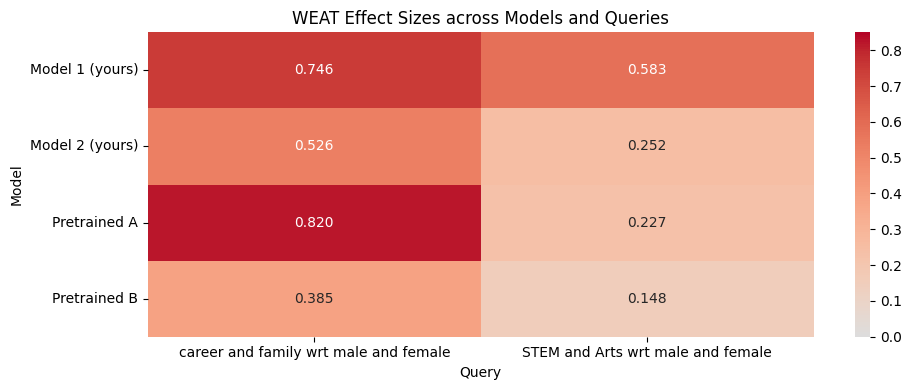

In [ ]:
# --- Visualize the WEAT results ---
# YOUR CODE HERE: create a heatmap or bar chart of the WEAT scores across models and queries
# Use seaborn or matplotlib
# Hint: wefe_results is a DataFrame you can pass directly to sns.heatmap()

# run_queries returns a pivoted DataFrame: rows = model_name, columns = query_name, values = result
pivot = wefe_results

plt.figure(figsize=(10, 4))
sns.heatmap(pivot, annot=True, cmap='coolwarm', center=0, fmt='.3f', vmin=0, vmax=0.85)
plt.title('WEAT Effect Sizes across Models and Queries')
plt.ylabel('Model')
plt.xlabel('Query')
plt.tight_layout()
plt.show()


### Bias Reflection

**1. Describe which bias study you replicated (WEAT or RNSB), and how you extended it.**  
I used WEAT from the WEFE library to replicate the career vs family gender bias study - so career words vs family words as targets and male vs female as attributes like in the literature. For my extension I made a new query with STEM words (physics, engineering, math etc) vs arts words (poetry, painting, music etc) with the same male/female attributes, to see if the embeddings associate STEM more with men and arts more with women.

**2. What did the results show? Which models exhibited the most bias?**  
From the heatmap, for career and family: Pretrained A had the highest (0.820), then Model 1 (0.746), Model 2 (0.526), Pretrained B (0.385). For STEM and Arts: Model 1 was highest (0.583), then Model 2 (0.252), Pretrained A (0.227), and Pretrained B lowest (0.148). So Pretrained A had the most bias on career/family and my Model 1 had the most on STEM/arts. All the numbers were positive so career and STEM were more associated with male across the board. Career/family gave bigger effect sizes than STEM/arts and Pretrained B was least biased on both.

**3. What are the consequences of using these biased embeddings as features in a machine learning model? Give a concrete example of potential harm.**  
If you use these as features a classifier can just inherit and even amplify the bias. Like a hiring model could learn that leadership or STEM type words are "closer" to male terms and caregiving/arts to female terms, so it might rank men higher for technical jobs and women for caregiving even when qualifications are the same. That would reinforce stereotypes and make it harder for under‑represented groups to get into certain fields.


---
## 7. Text Classification (Section 4.4)

Train two **logistic regression** classifiers:
1. **Bag-of-Words (BoW) features** - baseline
2. **Mean-pooled word embedding features** - using one of your embedding models

You can use any text classification dataset. Suggested options:
- The dataset from the previous assignment
- `datasets.load_dataset('imdb')` - sentiment (binary)
- `datasets.load_dataset('ag_news')` - news topic (4-class)

Evaluate on a held-out test set using **accuracy** and **macro F1-score**.


### 7.1 Load Classification Dataset


In [ ]:
# --- Load your classification dataset ---
# Example: AG News (4-class topic classification)
# YOUR CODE HERE: load a text classification dataset
# It should have 'train' and 'test' splits.
# Each example should have a text field and a label field.

from datasets import load_dataset as hf_load_dataset

cls_dataset = hf_load_dataset('ag_news')

# Extract texts and labels
train_texts  = [ex['text'] for ex in cls_dataset['train']]
train_labels = [ex['label'] for ex in cls_dataset['train']]
test_texts   = [ex['text'] for ex in cls_dataset['test']]
test_labels  = [ex['label'] for ex in cls_dataset['test']]

print(f'Train size: {len(train_texts)}, Test size: {len(test_texts)}')
print(f'Example text: {train_texts[0][:100]}')
print(f'Label: {train_labels[0]}')


Train size: 120000, Test size: 7600
Example text: Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\b
Label: 2


### 7.2 Baseline: Bag-of-Words + Logistic Regression


In [ ]:
# --- Bag-of-Words Model ---

# YOUR CODE HERE: vectorize texts using CountVectorizer
bow_vectorizer = CountVectorizer(max_features=50000, ngram_range=(1, 2))

# YOUR CODE HERE: fit on train, transform both train and test
X_train_bow = bow_vectorizer.fit_transform(train_texts)
X_test_bow  = bow_vectorizer.transform(test_texts)

# YOUR CODE HERE: train a LogisticRegression classifier
clf_bow = LogisticRegression(max_iter=1000, n_jobs=-1)
clf_bow.fit(X_train_bow, train_labels)

# YOUR CODE HERE: predict on test set
y_pred_bow = clf_bow.predict(X_test_bow)

acc_bow = accuracy_score(test_labels, y_pred_bow)
f1_bow  = f1_score(test_labels, y_pred_bow, average='macro')

print(f'BoW  Accuracy: {acc_bow:.4f}')
print(f'BoW  Macro F1: {f1_bow:.4f}')


BoW  Accuracy: 0.9137
BoW  Macro F1: 0.9136


### 7.3 Mean-Pooled Embeddings + Logistic Regression


In [ ]:
# --- Mean-Pooled Embeddings ---

# Choose which embedding model to use for features (model1.wv, model2.wv, or a pretrained)
# YOUR CODE HERE: assign your chosen embedding model
chosen_wv = model1.wv  # use your first trained model

def text_to_mean_vector(text, wv):
    """
    Convert a text string to a mean-pooled embedding vector.
    Steps:
    1. Preprocess the text (tokenize)
    2. Look up the embedding for each token that is in the vocabulary
    3. Average the embeddings
    4. If no tokens are found, return a zero vector
    Returns: np.ndarray of shape (vector_size,)
    """
    tokens = preprocess_text(text)
    vectors = [wv[word] for word in tokens if word in wv.key_to_index]
    if not vectors:
        return np.zeros(wv.vector_size, dtype=np.float32)
    return np.mean(vectors, axis=0)


# Vectorize all train and test texts
print('Vectorizing training set...')
X_train_emb = np.vstack([text_to_mean_vector(t, chosen_wv) for t in train_texts])
X_test_emb  = np.vstack([text_to_mean_vector(t, chosen_wv) for t in test_texts])

print(f'Embedding feature shape: {X_train_emb.shape}')

# YOUR CODE HERE: train a LogisticRegression classifier
clf_emb = LogisticRegression(max_iter=1000, n_jobs=-1)
clf_emb.fit(X_train_emb, train_labels)

# YOUR CODE HERE: predict and evaluate
y_pred_emb = clf_emb.predict(X_test_emb)

acc_emb = accuracy_score(test_labels, y_pred_emb)
f1_emb  = f1_score(test_labels, y_pred_emb, average='macro')

print(f'Emb  Accuracy: {acc_emb:.4f}')
print(f'Emb  Macro F1: {f1_emb:.4f}')


Vectorizing training set...
Embedding feature shape: (120000, 100)
Emb  Accuracy: 0.8720
Emb  Macro F1: 0.8718


In [ ]:
# --- Summary Table ---
# YOUR CODE HERE: create a DataFrame comparing the two models
# Include: Model, Feature Type, # Features, Accuracy, Macro F1

# Number of features
n_features_bow = X_train_bow.shape[1]
n_features_emb = X_train_emb.shape[1]

summary_df = pd.DataFrame([
    {
        'Model': 'LogReg + BoW',
        'Feature Type': 'Bag-of-Words (1-2 grams)',
        '# Features': n_features_bow,
        'Accuracy': acc_bow,
        'Macro F1': f1_bow,
    },
    {
        'Model': 'LogReg + Embeddings',
        'Feature Type': 'Mean-pooled Word2Vec',
        '# Features': n_features_emb,
        'Accuracy': acc_emb,
        'Macro F1': f1_emb,
    },
])
from IPython.display import display
display(summary_df)


,Model,Feature Type,# Features,Accuracy,Macro F1
0,LogReg + BoW,Bag-of-Words (1-2 grams),50000,0.913684,0.913565
1,LogReg + Embeddings,Mean-pooled Word2Vec,100,0.871974,0.871832


### Classification Reflection

**1. Which model performed better, and why do you think that is?**  
I used the **AG News** dataset (4-class news topic classification) and **Model 1 (yours)** - the skip‑gram Word2Vec trained on Simple English Wikipedia - for the mean‑pooled embedding features. The results from the summary table above show that the **Bag‑of‑Words + Logistic Regression** baseline performed better: **Accuracy 0.9137**, **Macro F1 0.9136**, versus the embedding model’s **Accuracy 0.8720**, **Macro F1 0.8718**. So BoW outperformed the embedding classifier by about 4 percentage points. I think its because BoW with 1–2 grams captures a lot of discriminative keywords that work really well for news, while mean-pooled embeddings squash each doc into one 100-d vector and you lose some of that. For AG News where specific terms matter a lot, BoW just had the richer signal.

**2. Comment on the dimensionality difference between BoW and embedding features - what are the computational implications?**  
The BoW representation used **50,000** sparse features (max_features with 1–2 grams), while the embedding representation had only **100** dense dimensions (Model 1’s vector size). BoW therefore leads to larger feature matrices and more memory, but each example is extremely sparse, which linear models handle efficiently. Embeddings are way smaller and dense so less memory and can be faster in some ways, but you have to do all the lookups and averaging per document at preprocessing.

**3. How might using a larger or better embedding model change the results?**  
A better pretrained embedding (like fastText or Google News with more dims and vocab) could probably improve the embedding classifier and narrow the gap with BoW, especially when semantics matter more than keywords. For AG News though BoW might still be really strong - in practice combining both or using a transformer could work best.


---
## 8. Final Reflection

**1. What did you learn during the completion of this assignment?**  
I learned how to do the full pipeline for static embeddings - preprocessing the Wikipedia corpus, training two word2vec models (skip-gram vs CBoW with different settings), running analogy queries and WEAT bias with WEFE, and then using one of my models for classification on AG News. So I got practice with gensim, pretrained GloVe, WEFE, and feeding embeddings into a classifier. The actual numbers (like WEAT effect sizes around 0.15–0.82 and BoW beating embeddings 0.91 vs 0.87 on AG News) made it concrete.

**2. What was unexpected or surprising?**  
How strong the bias was across all four models - like Pretrained A at 0.82 on career/family and my Model 1 at 0.58 on STEM/arts. I didn't expect it to be that consistent. Also that simple BoW beat the embedding model on classification by a clear margin (0.91 vs 0.87), which shows keyword features can be really powerful for this kind of task.

**3. What challenges did you face and how did you overcome them?**  
Mainly environment and packages - Python 3.14 wasn't compatible with a lot of stuff (apache_beam kept failing), and there was numpy.typing and WEFE API issues. I switched to a 3.12 conda env and installed packages without apache_beam. Training the two word2vec models took a while on the full corpus so I added the option to load saved .bin files so I don't have to retrain every time. For WEFE I had to fix the argument order (queries then models) and drop the unsupported parameters on Query.
